## Import libraries

In [1]:
import tomopy
from helperFunctions import MoviePlotter
from tomoDataClass import tomoData
from alignment_methods import reprojection_consistency_score
import h5py
import numpy as np

In [2]:
def tomo_data(file,redo_align=False):
    try:
        with h5py.File(file) as hf:
            projs = hf['data'][...]
            angles = hf['angles'][...]
    except KeyError:
        with h5py.File(file) as hf:
            projs = hf['data'][...]
            angles = hf['angles'][...]
    angles = angles * np.pi / 180
    return projs, angles

## Import real Data

In [3]:
# Set projection angles
filename = "/Users/levihancock/Library/CloudStorage/Box-Box/BYU_CXI_Research_Team/ProjectFolders/IFE-STAR/IFE-Ptycho-Tomo/APS_2ID_GUP1013052_August_2025/levi_tomoReconstructions/tomo_data_run_final_2.hdf5"

projections_og, angles = tomo_data(filename, redo_align=True)
print(projections_og.shape)


(558, 585, 1810)


In [4]:

#downsample projections
# projections = tuple(pyramid_gaussian(projections_og, max_layer=1, downscale=4, sigma=None, preserve_range=False))[1]
projections = projections_og[::2,::4,::4]
angles = angles[::2]
print("Angles:", angles)
print(projections.shape)

print("Projections through object")
MoviePlotter(projections)

tomo = tomoData(projections, angles)

Angles: [-1.25655201e+00 -1.24957643e+00 -1.23911307e+00 -1.23211833e+00
 -1.22514276e+00 -1.21816718e+00 -1.20768466e+00 -1.20070908e+00
 -1.19373351e+00 -1.18327015e+00 -1.17627541e+00 -1.16931900e+00
 -1.16230510e+00 -1.15184173e+00 -1.14484700e+00 -1.13789059e+00
 -1.12740806e+00 -1.12041332e+00 -1.11343775e+00 -1.10646217e+00
 -1.09597965e+00 -1.08900407e+00 -1.08202850e+00 -1.07154597e+00
 -1.06457040e+00 -1.05759482e+00 -1.05060009e+00 -1.04013672e+00
 -1.03316115e+00 -1.02266904e+00 -1.01221526e+00 -1.00523969e+00
 -9.98244950e-01 -9.87800752e-01 -9.80786851e-01 -9.73811276e-01
 -9.66835702e-01 -9.56372340e-01 -9.49377602e-01 -9.42421191e-01
 -9.31919502e-01 -9.24943927e-01 -9.17968353e-01 -9.10992779e-01
 -9.00500671e-01 -8.93649661e-01 -8.86530359e-01 -8.76076579e-01
 -8.69101004e-01 -8.62106266e-01 -8.55130692e-01 -8.44667330e-01
 -8.37672592e-01 -8.30697017e-01 -8.20233656e-01 -8.13238918e-01
 -8.06282507e-01 -7.99287769e-01 -7.88805243e-01 -7.81829669e-01
 -7.74854094e-01 

Output()

## Align Data

In [5]:
#Show bad reconstruction prior to alignment
tomo.reset_workingProjections(x_size=None, y_size=None) #You can adjust these for tighter cropping
tomo.normalize(isPhaseData=True)

tomo.reconstruct(algorithm='art')
print("\nBad reconstruction prior to alignment")
badRecon = tomo.recon.copy()
MoviePlotter(badRecon)



Normalizing projections


Using CPU-based reconstruction. Algorithm:  art
Reconstruction completed.

Bad reconstruction prior to alignment


Output()

Computing reprojections of reconstruction...
Computing per-angle NRMSE...


NRMSE per angle: 100%|██████████| 279/279 [00:00<00:00, 2634.54it/s]


─── Reprojection Consistency Score ───────────────────────
  RCS (mean NRMSE):   0.6682
  Best  angle [ 278]:  NRMSE = 0.0534
  Worst angle [ 229]:  NRMSE = 1.6622
  Std across angles:  0.2868
  Verdict:  ✗  Poor — significant misalignment or reconstruction failure.
───────────────────────────────────────────────────────────



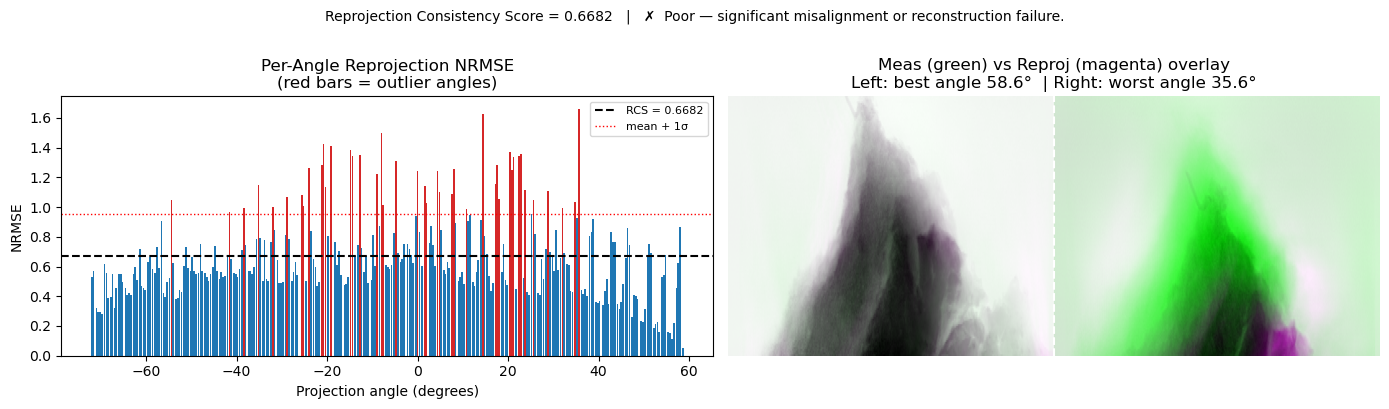

In [6]:
# Reprojection Consistency Score — before alignment
rcs_before, _, _ = reprojection_consistency_score(tomo, plot=True)



Normalizing projections


Cross-Correlation Alignment  [4x downsample | full frame | gradient mode]


Iteration 1/10: 100%|██████████| 278/278 [00:01<00:00, 210.55it/s]


Iteration 1: avg shift = 15.8789 px, max shift = 93.4762 px


Iteration 2/10: 100%|██████████| 278/278 [00:01<00:00, 259.82it/s]


Iteration 2: avg shift = 1.4932 px, max shift = 10.8255 px


...

Iteration 3: avg shift = 0.0283 px, max shift = 0.9330 px


Iteration 4/5: 100%|██████████| 278/278 [00:02<00:00, 92.72it/s] 


Iteration 4: avg shift = 0.0237 px, max shift = 0.2912 px


Iteration 5/5: 100%|██████████| 278/278 [00:02<00:00, 93.78it/s] 


Iteration 5: avg shift = 0.0147 px, max shift = 0.2683 px
Maximum iterations reached without convergence.


VMF Alignment (sigma=1.1484375, upsample=50, window=soft_roi, gradient=True)
  Iteration 1: Mean Correction = 0.9557 px


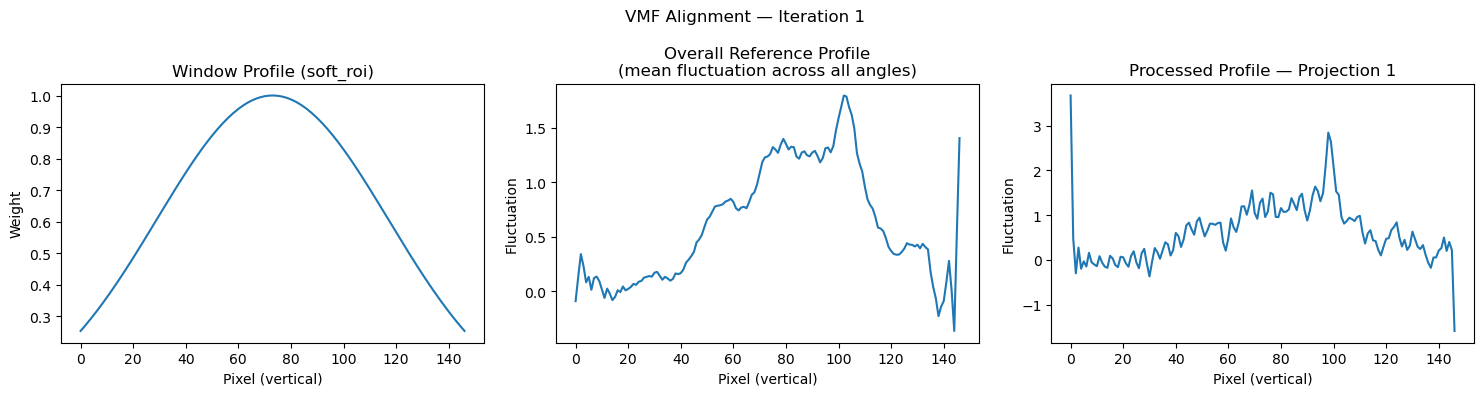

  Iteration 2: Mean Correction = 0.6732 px


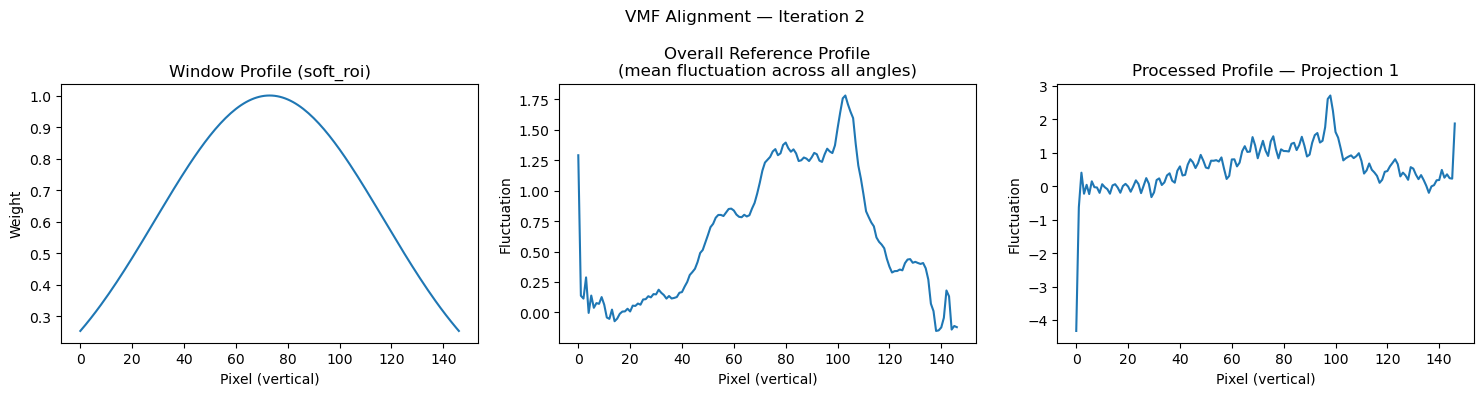

  Iteration 3: Mean Correction = 0.5229 px


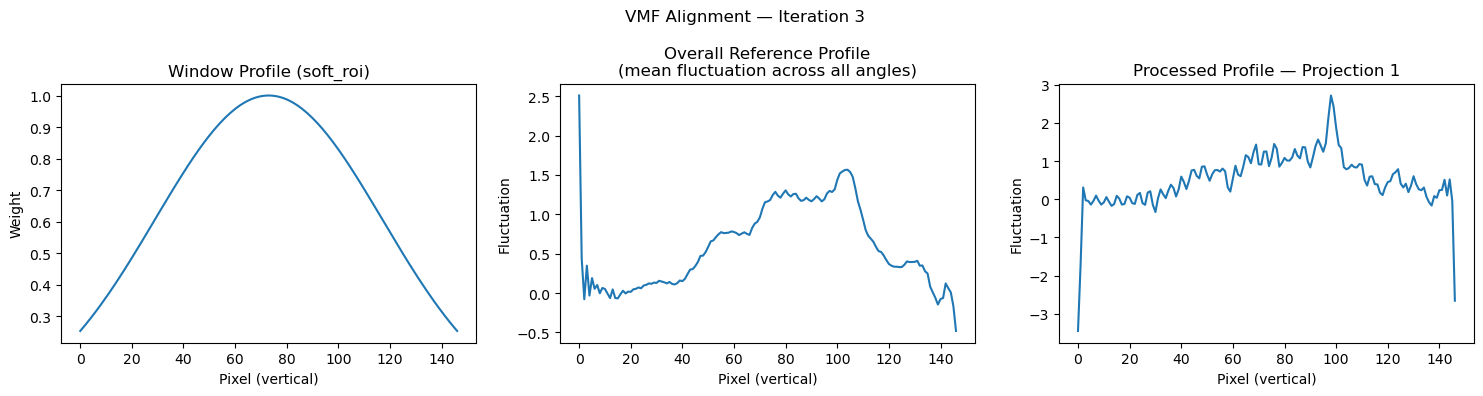

  Iteration 4: Mean Correction = 0.3364 px


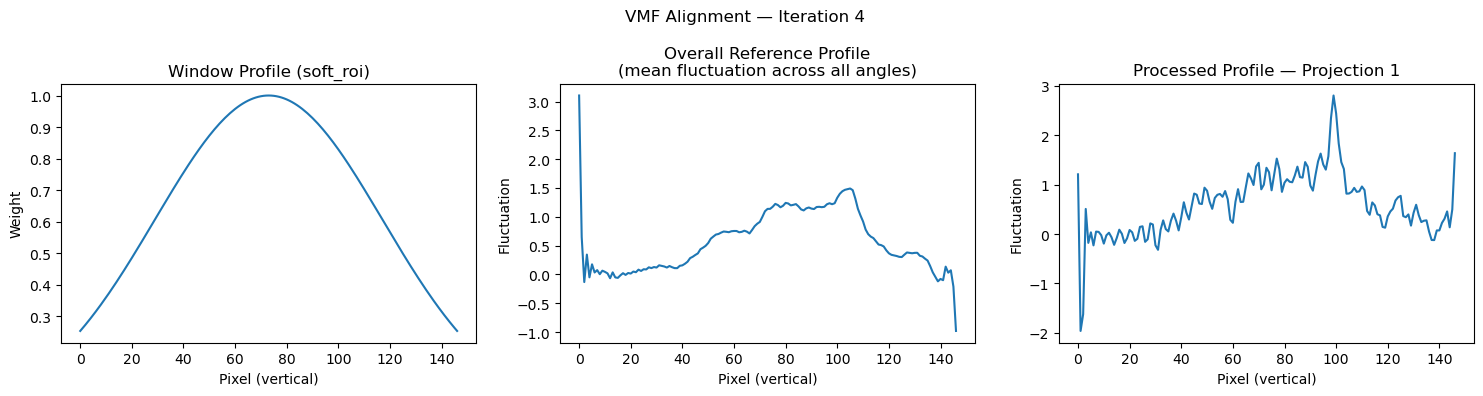

  Iteration 5: Mean Correction = 0.5262 px


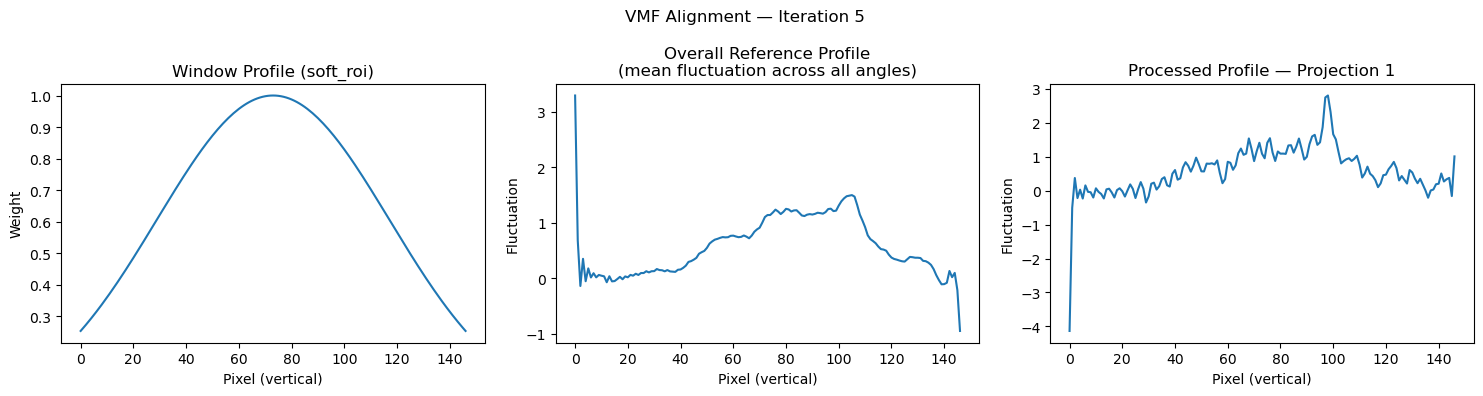



Projection Matching Alignment (PMA) [optical_flow]
Centering Projections
Original center: 239.75
Center of frame: 226
Aligned projections shifted by -13.25 pixels
Projections are currently centered at pixel 226.75. Residual offset: 0.75

--- PMA Level 2 (4x downsampled, 5 iterations) ---


PMA Level 2 iterations:   0%|          | 0/5 [00:00<?, ?it/s]

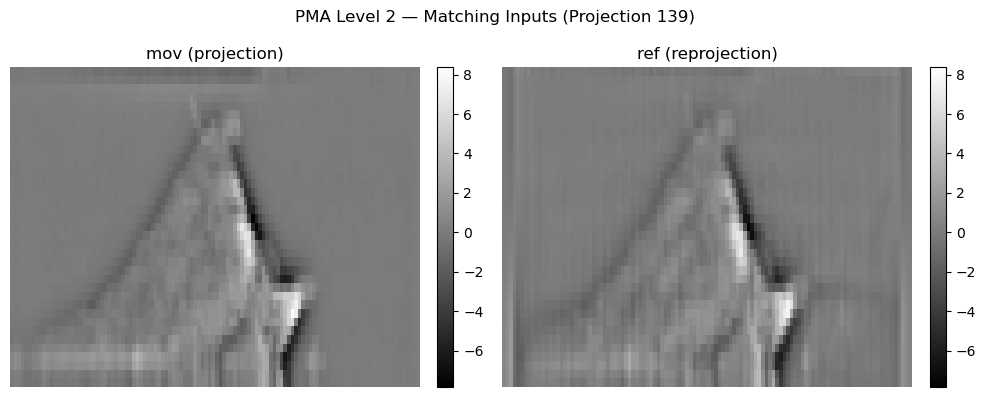

PMA Level 2 iterations:  20%|██        | 1/5 [00:03<00:14,  3.71s/it]

  Iter 1: avg=0.1864 px


PMA Level 2 iterations:  40%|████      | 2/5 [00:06<00:10,  3.38s/it]

  Iter 2: avg=0.1443 px


PMA Level 2 iterations:  60%|██████    | 3/5 [00:10<00:06,  3.34s/it]

...

PMA Level 2 iterations:  80%|████████  | 4/5 [00:13<00:03,  3.37s/it]

  Iter 4: avg=0.0826 px


PMA Level 2 iterations: 100%|██████████| 5/5 [00:16<00:00,  3.32s/it]

  Iter 5: avg=0.0715 px

--- PMA Level 1 (2x downsampled, 5 iterations) ---



PMA Level 1 iterations:   0%|          | 0/5 [00:00<?, ?it/s]

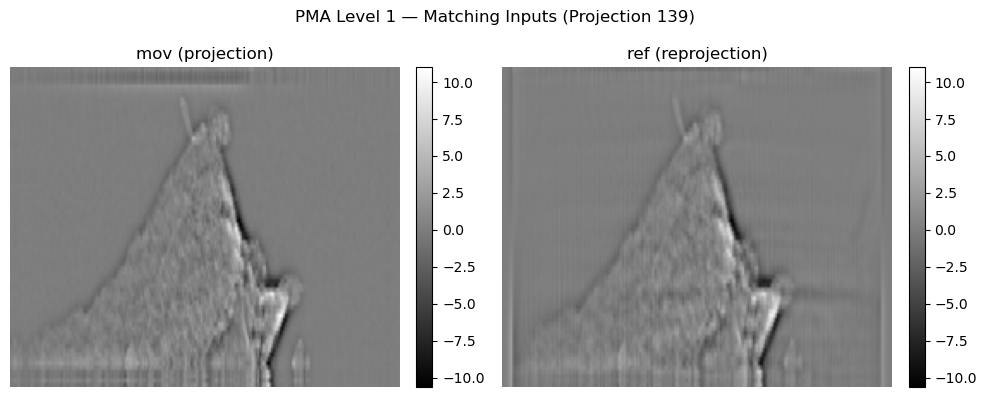

PMA Level 1 iterations:  20%|██        | 1/5 [00:07<00:31,  7.96s/it]

  Iter 1: avg=0.0981 px


PMA Level 1 iterations:  40%|████      | 2/5 [00:14<00:20,  6.90s/it]

  Iter 2: avg=0.1070 px


PMA Level 1 iterations:  60%|██████    | 3/5 [00:20<00:13,  6.53s/it]

...

PMA Level 1 iterations:  80%|████████  | 4/5 [00:26<00:06,  6.44s/it]

  Iter 4: avg=0.0965 px


PMA Level 1 iterations: 100%|██████████| 5/5 [00:33<00:00,  6.62s/it]

  Iter 5: avg=0.0812 px

--- PMA Level 0 (1x downsampled, 2 iterations) ---



PMA Level 0 iterations:   0%|          | 0/2 [00:00<?, ?it/s]

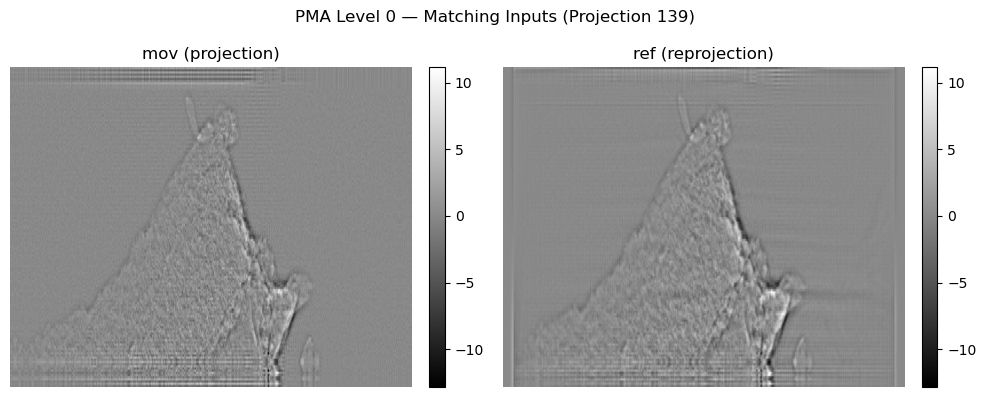

PMA Level 0 iterations:  50%|█████     | 1/2 [00:27<00:27, 27.95s/it]

  Iter 1: avg=0.0730 px


PMA Level 0 iterations: 100%|██████████| 2/2 [00:54<00:00, 27.38s/it]

  Iter 2: avg=0.0763 px



PMA complete.


Apply shifts to final projections: 100%|██████████| 279/279 [00:05<00:00, 55.28it/s]


In [7]:
tomo.reset_workingProjections(x_size=None, y_size=None)
tomo.normalize(isPhaseData=True)

#Best XC params from sweep:
# Coarse passes: stepRatio=0.9 (stable global convergence)
tomo.cross_correlate_align(tolerance=0, maxShiftTolerance=0, max_iterations=10, stepRatio=0.9, yROI_Range=None, xROI_Range=None, isFull360=False, downsample=4, use_grad=True)
tomo.cross_correlate_align(tolerance=0, maxShiftTolerance=0, max_iterations=10, stepRatio=0.9, yROI_Range=None, xROI_Range=None, isFull360=False, downsample=2, use_grad=True)
# Final pass: stepRatio=0.75-0.8 with more iterations (fine-scale sharpness)
tomo.cross_correlate_align(tolerance=0, maxShiftTolerance=0, max_iterations=5, stepRatio=0.8, yROI_Range=None, xROI_Range=None, isFull360=False, downsample=1, use_grad=True)


#Best VMF params from sweep:
tomo.vertical_mass_fluctuation_align(tolerance=0, max_iterations=5, y_range=None, sigma=None, smooth_sigma=1.0, window='soft_roi', roi_sigma=0.3, use_gradient=True, plot=True)

tomo.PMA(max_iterations=5, tolerance=0, algorithm='art', levels=3, scale=2, iterations_per_level=[5,5,2], shift_method='optical_flow', of_sigma=3.0, plot=True)
tomo.make_updates_shift()

In [ ]:
tomo.makeNotebookProjMovie()
print(tomo.ang)
tomo.reconstruct(algorithm='art')
print("\nGood Reconstruction after alignment")
tomo.makeNotebookReconMovie()

Output()

[-1.25655201e+00 -1.24957643e+00 -1.23911307e+00 -1.23211833e+00
 -1.22514276e+00 -1.21816718e+00 -1.20768466e+00 -1.20070908e+00
 -1.19373351e+00 -1.18327015e+00 -1.17627541e+00 -1.16931900e+00
 -1.16230510e+00 -1.15184173e+00 -1.14484700e+00 -1.13789059e+00
 -1.12740806e+00 -1.12041332e+00 -1.11343775e+00 -1.10646217e+00
 -1.09597965e+00 -1.08900407e+00 -1.08202850e+00 -1.07154597e+00
 -1.06457040e+00 -1.05759482e+00 -1.05060009e+00 -1.04013672e+00
 -1.03316115e+00 -1.02266904e+00 -1.01221526e+00 -1.00523969e+00
 -9.98244950e-01 -9.87800752e-01 -9.80786851e-01 -9.73811276e-01
 -9.66835702e-01 -9.56372340e-01 -9.49377602e-01 -9.42421191e-01
 -9.31919502e-01 -9.24943927e-01 -9.17968353e-01 -9.10992779e-01
 -9.00500671e-01 -8.93649661e-01 -8.86530359e-01 -8.76076579e-01
 -8.69101004e-01 -8.62106266e-01 -8.55130692e-01 -8.44667330e-01
 -8.37672592e-01 -8.30697017e-01 -8.20233656e-01 -8.13238918e-01
 -8.06282507e-01 -7.99287769e-01 -7.88805243e-01 -7.81829669e-01
 -7.74854094e-01 -7.64361

Output()

Computing reprojections of reconstruction...
Computing per-angle NRMSE...


NRMSE per angle: 100%|██████████| 279/279 [00:00<00:00, 1984.79it/s]


─── Reprojection Consistency Score ───────────────────────
  RCS (mean NRMSE):   0.6124
  Best  angle [ 278]:  NRMSE = 0.0581
  Worst angle [ 121]:  NRMSE = 1.2436
  Std across angles:  0.1945
  Verdict:  ✗  Poor — significant misalignment or reconstruction failure.
───────────────────────────────────────────────────────────



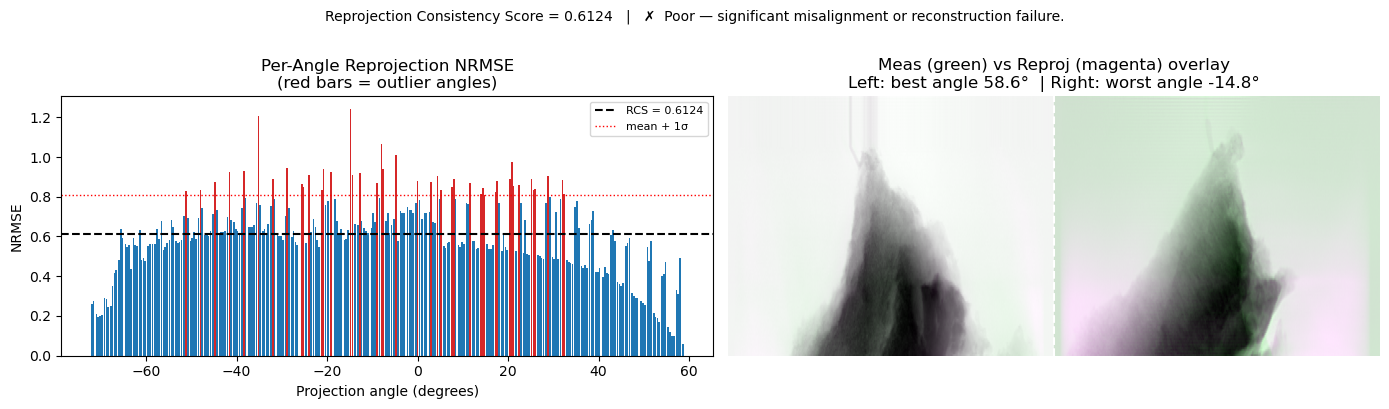

  ALIGNMENT QUALITY SUMMARY
  Metric                   Before    After          Δ
  --------------------------------------------------
  RCS (lower = better)     0.6682   0.6124    +0.0558


In [9]:
# Reprojection Consistency Score — after alignment
rcs_after, _, _ = reprojection_consistency_score(tomo, plot=True)

print("=" * 52)
print("  ALIGNMENT QUALITY SUMMARY")
print("=" * 52)
print(f"  {'Metric':<22} {'Before':>8} {'After':>8} {'Δ':>10}")
print(f"  {'-'*50}")
print(f"  {'RCS (lower = better)':<22} {rcs_before:>8.4f} {rcs_after:>8.4f} {rcs_before - rcs_after:>+10.4f}")
print("=" * 52)